# 104. Qwen3 長文コンテキストと先頭偏重の検証

## 目的
長文コンテキストモデル（Qwen3-Embedding-0.6B）が先頭偏重バイアスを持つかを検証し、
チャンク戦略 vs 全文戦略の優劣を定量的に比較する。

## 検証内容
1. **位置感度テスト**: 全文 embedding と各段落 embedding の cos 類似度 → 先頭偏重の有無
2. **打ち切り長さ比較**: トークン打ち切り長さ vs Recall@10
3. **段落順序シャッフルテスト**: 正順 vs 逆順 embedding の cos 類似度 → 順序依存性
4. **チャンク vs 全文**: 全文1ベクトル / max-sim 集約 / 個別チャンク検索の3戦略比較
5. **E5 vs Qwen3 対比**: 長文活用能力の差異

## 対象モデル
| モデル | HF ID | 次元 | max tokens |
|--------|--------|------|------------|
| multilingual-e5-base | `intfloat/multilingual-e5-base` | 768 | 512 |
| Qwen3-Embedding-0.6B | `Qwen/Qwen3-Embedding-0.6B` | 1024 | 8192 |

## 前提
- `notebooks/101_chunking_data_preparation.ipynb` で作成した `data/101_articles_ja.pkl`, `data/101_articles_en.pkl` を使用

In [1]:
import gc, os, pickle, re, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer
from tqdm.auto import tqdm
sys.path.insert(0, "../src")

SEED = 42
DATA_DIR = "../data"

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def _vram_mb():
    """現在のGPU VRAMアロケーション量をMBで返す"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024**2
    return 0.0

def chunk_fixed_token(text, tokenizer, size, overlap=0):
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    if len(token_ids) == 0:
        return []
    step = max(1, size - overlap)
    chunks = []
    for start in range(0, len(token_ids), step):
        chunk_ids = token_ids[start : start + size]
        chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True).strip()
        if chunk_text:
            chunks.append(chunk_text)
        if start + size >= len(token_ids):
            break
    return chunks

def compute_retrieval_metrics(embeddings, article_ids, k=10, n_queries=1000):
    n = len(embeddings)
    rng = np.random.default_rng(SEED)
    query_ids = rng.choice(n, min(n_queries, n), replace=False)
    recalls, mrrs = [], []
    for qid in query_ids:
        same_art = np.where((article_ids == article_ids[qid]) & (np.arange(n) != qid))[0]
        if len(same_art) == 0:
            continue
        sims = embeddings[qid] @ embeddings.T
        sims[qid] = -2.0
        topk_ids = np.argsort(sims)[-k:][::-1]
        found = len(set(same_art) & set(topk_ids))
        recalls.append(found / min(len(same_art), k))
        rr = 0.0
        for rank, idx in enumerate(topk_ids, 1):
            if idx in same_art:
                rr = 1.0 / rank
                break
        mrrs.append(rr)
    return {f"Recall@{k}": float(np.mean(recalls)), "MRR": float(np.mean(mrrs)), "n_queries": len(recalls)}

print("Setup complete.")

Setup complete.


In [2]:
with open(os.path.join(DATA_DIR, "101_articles_ja.pkl"), "rb") as f:
    articles_ja = pickle.load(f)
with open(os.path.join(DATA_DIR, "101_articles_en.pkl"), "rb") as f:
    articles_en = pickle.load(f)

tokenizer_e5 = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-base")
tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen3-Embedding-0.6B")

# 5段落以上の記事を最大200件選択
MIN_PARAS = 5
N_SAMPLE = 200

long_ja = [a for a in articles_ja if len(a["paragraphs"]) >= MIN_PARAS][:N_SAMPLE]
long_en = [a for a in articles_en if len(a["paragraphs"]) >= MIN_PARAS][:N_SAMPLE]

print(f"JA: {len(long_ja)} articles with >= {MIN_PARAS} paragraphs")
print(f"EN: {len(long_en)} articles with >= {MIN_PARAS} paragraphs")

JA: 200 articles with >= 5 paragraphs
EN: 200 articles with >= 5 paragraphs


## 2. 位置感度テスト

全文 embedding と各段落 embedding のコサイン類似度を段落位置ごとに計測し、先頭偏重の有無を可視化する。

In [3]:
def position_sensitivity(articles, model, tokenizer, prefix="", max_paras=10, max_tokens=8192):
    """全文embeddingと各段落embeddingのcos類似度を位置ごとに計算。
    全文テキストは max_tokens で打ち切る。"""
    position_sims = {i: [] for i in range(max_paras)}

    for art in tqdm(articles, desc="Position sensitivity"):
        paras = art["paragraphs"][:max_paras]
        if len(paras) < 2:
            continue

        # 全文embedding（max_tokensで打ち切り）
        full_text = "\n\n".join(paras)
        full_ids = tokenizer.encode(full_text, add_special_tokens=False)[:max_tokens]
        full_text = tokenizer.decode(full_ids, skip_special_tokens=True)
        full_input = f"{prefix}{full_text}" if prefix else full_text
        full_emb = model.encode([full_input], batch_size=1,
                                normalize_embeddings=True, show_progress_bar=False)[0]
        torch.cuda.empty_cache()

        # 段落embeddingは短いのでまとめてencode
        para_texts = [f"{prefix}{p}" if prefix else p for p in paras]
        para_embs = model.encode(para_texts, batch_size=8,
                                 normalize_embeddings=True, show_progress_bar=False)
        torch.cuda.empty_cache()

        # 各段落位置のcos類似度
        for i, pe in enumerate(para_embs):
            sim = float(np.dot(full_emb, pe))
            position_sims[i].append(sim)

        del full_emb, para_embs
        torch.cuda.empty_cache()

    return position_sims

In [4]:
_pos_npz = os.path.join(DATA_DIR, "104_position_sensitivity.npz")
if os.path.exists(_pos_npz):
    print(f"Results already exist at {_pos_npz} — skipping computation, loading from file")
    _pos_data = np.load(_pos_npz, allow_pickle=True)
    pos_e5_ja = _pos_data["pos_e5_ja"].item()
    pos_e5_en = _pos_data["pos_e5_en"].item()
    pos_qwen_ja = _pos_data["pos_qwen_ja"].item()
    pos_qwen_en = _pos_data["pos_qwen_en"].item()
    del _pos_data
else:
    # E5 (max 512 tokens)
    print(f"[VRAM before E5] {_vram_mb():.0f} MB")
    model_e5 = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")
    print(f"[VRAM after E5 load] {_vram_mb():.0f} MB")

    pos_e5_ja = position_sensitivity(long_ja, model_e5, tokenizer_e5, prefix="passage: ", max_tokens=512)
    pos_e5_en = position_sensitivity(long_en, model_e5, tokenizer_e5, prefix="passage: ", max_tokens=512)

    del model_e5
    clear_gpu()
    print(f"[VRAM after E5 cleanup] {_vram_mb():.0f} MB")

    # Qwen3 (max 8192 tokens)
    print(f"\n[VRAM before Qwen3] {_vram_mb():.0f} MB")
    model_qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")
    print(f"[VRAM after Qwen3 load] {_vram_mb():.0f} MB")

    pos_qwen_ja = position_sensitivity(long_ja, model_qwen, tokenizer_qwen, prefix="", max_tokens=8192)
    pos_qwen_en = position_sensitivity(long_en, model_qwen, tokenizer_qwen, prefix="", max_tokens=8192)

    del model_qwen
    clear_gpu()
    print(f"[VRAM after Qwen3 cleanup] {_vram_mb():.0f} MB")

    # Save position sensitivity results
    np.savez(_pos_npz,
             pos_e5_ja=pos_e5_ja, pos_e5_en=pos_e5_en,
             pos_qwen_ja=pos_qwen_ja, pos_qwen_en=pos_qwen_en)
    print(f"Saved: {_pos_npz}")

print("\nPosition sensitivity computed.")

Results already exist at ../data/104_position_sensitivity.npz — skipping computation, loading from file

Position sensitivity computed.


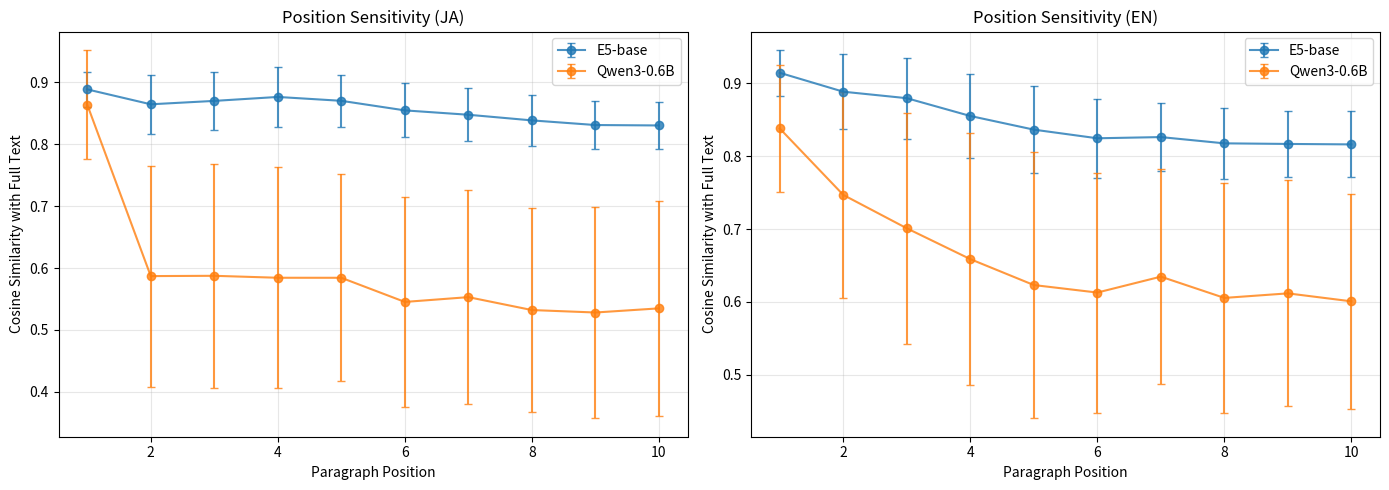

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lang, pos_e5, pos_qwen in [
    (axes[0], "JA", pos_e5_ja, pos_qwen_ja),
    (axes[1], "EN", pos_e5_en, pos_qwen_en),
]:
    for label, pos_data, color in [
        ("E5-base", pos_e5, "tab:blue"),
        ("Qwen3-0.6B", pos_qwen, "tab:orange"),
    ]:
        positions = []
        means = []
        stds = []
        for i in range(10):
            if len(pos_data[i]) > 10:
                positions.append(i + 1)
                means.append(np.mean(pos_data[i]))
                stds.append(np.std(pos_data[i]))

        ax.errorbar(positions, means, yerr=stds, marker="o", label=label,
                     color=color, capsize=3, alpha=0.8)

    ax.set_xlabel("Paragraph Position")
    ax.set_ylabel("Cosine Similarity with Full Text")
    ax.set_title(f"Position Sensitivity ({lang})")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "104_position_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. 打ち切り長さ比較

記事テキストを異なるトークン数で打ち切り、段落ベースの Recall@10 への影響を評価。

In [6]:
def adaptive_batch_size(max_tokens: int, base_batch: int = 64) -> int:
    """トークン長に応じてbatch_sizeを調整"""
    if max_tokens <= 256:
        return base_batch
    elif max_tokens <= 512:
        return max(16, base_batch // 2)
    elif max_tokens <= 1024:
        return max(8, base_batch // 4)
    elif max_tokens <= 2048:
        return max(4, base_batch // 8)
    else:  # 4096+
        return 2


def truncate_and_evaluate(articles, model, tokenizer, prefix, truncation_lengths, lang):
    """異なる打ち切り長さでembeddingを生成し、Recall@10を計算"""
    results = []

    for trunc_len in truncation_lengths:
        passages = []
        article_ids = []
        for art in articles:
            paras = []
            for p in art["paragraphs"]:
                if len(p) >= 80:
                    tokens = tokenizer.encode(p, add_special_tokens=False)[:trunc_len]
                    text = tokenizer.decode(tokens, skip_special_tokens=True).strip()
                    if text:
                        paras.append(text)
                if len(paras) >= 5:
                    break
            if len(paras) >= 3:
                passages.extend(paras)
                article_ids.extend([art["article_id"]] * len(paras))

        article_ids = np.array(article_ids)
        texts = [f"{prefix}{p}" for p in passages] if prefix else passages
        bs = adaptive_batch_size(trunc_len)
        embs = model.encode(texts, batch_size=bs,
                            normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

        ret = compute_retrieval_metrics(embs, article_ids, k=10)
        results.append({
            "trunc_tokens": trunc_len,
            "n_passages": len(passages),
            **ret,
        })
        print(f"  trunc={trunc_len}: {len(passages)} passages, bs={bs}, R@10={ret['Recall@10']:.4f}")

        del embs, texts, passages, article_ids
        torch.cuda.empty_cache()

    return results

In [7]:
csv_path_trunc = os.path.join(DATA_DIR, "104_truncation_results.csv")
if os.path.exists(csv_path_trunc):
    print(f"Results already exist at {csv_path_trunc} — skipping computation, loading from file")
    df_trunc = pd.read_csv(csv_path_trunc)
    # Reconstruct per-model result lists for plotting
    trunc_e5_ja = df_trunc[(df_trunc["model"] == "E5-base") & (df_trunc["lang"] == "ja")].to_dict("records")
    trunc_e5_en = df_trunc[(df_trunc["model"] == "E5-base") & (df_trunc["lang"] == "en")].to_dict("records")
    trunc_qwen_ja = df_trunc[(df_trunc["model"] == "Qwen3-0.6B") & (df_trunc["lang"] == "ja")].to_dict("records")
    trunc_qwen_en = df_trunc[(df_trunc["model"] == "Qwen3-0.6B") & (df_trunc["lang"] == "en")].to_dict("records")
    print(f"Loaded {len(df_trunc)} rows")
else:
    # E5
    print(f"[VRAM before E5] {_vram_mb():.0f} MB")
    model_e5 = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")
    print(f"[VRAM after E5 load] {_vram_mb():.0f} MB")

    print("E5-base JA:")
    trunc_e5_ja = truncate_and_evaluate(long_ja, model_e5, tokenizer_e5, "passage: ",
                                         [64, 128, 256, 384, 512], "ja")
    print("\nE5-base EN:")
    trunc_e5_en = truncate_and_evaluate(long_en, model_e5, tokenizer_e5, "passage: ",
                                         [64, 128, 256, 384, 512], "en")
    del model_e5
    clear_gpu()
    print(f"[VRAM after E5 cleanup] {_vram_mb():.0f} MB")

    # Qwen3
    print(f"\n[VRAM before Qwen3] {_vram_mb():.0f} MB")
    model_qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")
    print(f"[VRAM after Qwen3 load] {_vram_mb():.0f} MB")

    print("\nQwen3 JA:")
    trunc_qwen_ja = truncate_and_evaluate(long_ja, model_qwen, tokenizer_qwen, "",
                                           [128, 256, 512, 1024, 2048, 4096], "ja")
    print("\nQwen3 EN:")
    trunc_qwen_en = truncate_and_evaluate(long_en, model_qwen, tokenizer_qwen, "",
                                           [128, 256, 512, 1024, 2048, 4096], "en")
    del model_qwen
    clear_gpu()
    print(f"[VRAM after Qwen3 cleanup] {_vram_mb():.0f} MB")

    # Save truncation results
    trunc_rows = []
    for model_name, lang, data in [
        ("E5-base", "ja", trunc_e5_ja), ("E5-base", "en", trunc_e5_en),
        ("Qwen3-0.6B", "ja", trunc_qwen_ja), ("Qwen3-0.6B", "en", trunc_qwen_en),
    ]:
        for r in data:
            trunc_rows.append({"model": model_name, "lang": lang, **r})
    df_trunc = pd.DataFrame(trunc_rows)
    df_trunc.to_csv(csv_path_trunc, index=False)
    print(f"\nSaved: {csv_path_trunc} ({len(df_trunc)} rows)")

Results already exist at ../data/104_truncation_results.csv — skipping computation, loading from file
Loaded 22 rows


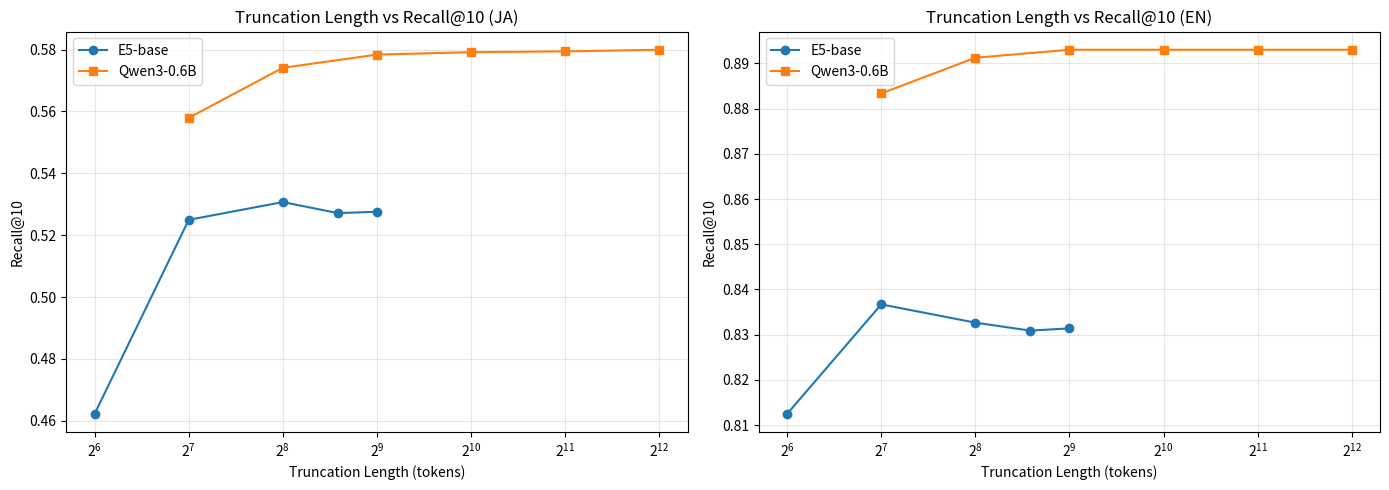

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lang, te5, tqwen in [
    (axes[0], "JA", trunc_e5_ja, trunc_qwen_ja),
    (axes[1], "EN", trunc_e5_en, trunc_qwen_en),
]:
    ax.plot([r["trunc_tokens"] for r in te5], [r["Recall@10"] for r in te5],
            marker="o", label="E5-base")
    ax.plot([r["trunc_tokens"] for r in tqwen], [r["Recall@10"] for r in tqwen],
            marker="s", label="Qwen3-0.6B")
    ax.set_xlabel("Truncation Length (tokens)")
    ax.set_ylabel("Recall@10")
    ax.set_title(f"Truncation Length vs Recall@10 ({lang})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log", base=2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "104_truncation_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. 段落順序シャッフルテスト

正順と逆順のembeddingのcos類似度を計測し、モデルの順序依存性を評価。

In [9]:
def order_sensitivity(articles, model, tokenizer, prefix="", max_tokens=8192):
    """正順 vs 逆順 embedding のcos類似度。
    max_tokens でテキストを打ち切り、attention OOM を防止する。"""
    sims = []
    for art in tqdm(articles, desc="Order sensitivity"):
        paras = art["paragraphs"]
        if len(paras) < 3:
            continue

        original = "\n\n".join(paras)
        reversed_text = "\n\n".join(paras[::-1])

        # max_tokens で打ち切り
        def _truncate(text):
            ids = tokenizer.encode(text, add_special_tokens=False)[:max_tokens]
            return tokenizer.decode(ids, skip_special_tokens=True)

        original = _truncate(original)
        reversed_text = _truncate(reversed_text)

        texts = [original, reversed_text]
        if prefix:
            texts = [f"{prefix}{t}" for t in texts]

        embs = model.encode(texts, batch_size=1,
                            normalize_embeddings=True, show_progress_bar=False)
        sim = float(np.dot(embs[0], embs[1]))
        sims.append(sim)

        del embs
        torch.cuda.empty_cache()

    return np.array(sims)


npz_path_order = os.path.join(DATA_DIR, "104_order_sensitivity.npz")
if os.path.exists(npz_path_order):
    print(f"Results already exist at {npz_path_order} — skipping computation, loading from file")
    _order_data = np.load(npz_path_order)
    order_e5_ja = _order_data["order_e5_ja"]
    order_e5_en = _order_data["order_e5_en"]
    order_qwen_ja = _order_data["order_qwen_ja"]
    order_qwen_en = _order_data["order_qwen_en"]
    del _order_data
else:
    # E5 (max 512 tokens)
    print(f"[VRAM before E5] {_vram_mb():.0f} MB")
    model_e5 = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")
    print(f"[VRAM after E5 load] {_vram_mb():.0f} MB")

    order_e5_ja = order_sensitivity(long_ja, model_e5, tokenizer_e5, prefix="passage: ", max_tokens=512)
    order_e5_en = order_sensitivity(long_en, model_e5, tokenizer_e5, prefix="passage: ", max_tokens=512)

    del model_e5
    clear_gpu()
    print(f"[VRAM after E5 cleanup] {_vram_mb():.0f} MB")

    # Qwen3 (max 8192 tokens)
    print(f"\n[VRAM before Qwen3] {_vram_mb():.0f} MB")
    model_qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")
    print(f"[VRAM after Qwen3 load] {_vram_mb():.0f} MB")

    order_qwen_ja = order_sensitivity(long_ja, model_qwen, tokenizer_qwen, prefix="", max_tokens=8192)
    order_qwen_en = order_sensitivity(long_en, model_qwen, tokenizer_qwen, prefix="", max_tokens=8192)

    del model_qwen
    clear_gpu()
    print(f"[VRAM after Qwen3 cleanup] {_vram_mb():.0f} MB")

    # Save order sensitivity arrays
    np.savez(npz_path_order,
             order_e5_ja=order_e5_ja, order_e5_en=order_e5_en,
             order_qwen_ja=order_qwen_ja, order_qwen_en=order_qwen_en)
    print(f"Saved: {npz_path_order}")

print("\nOrder sensitivity results:")
for name, sims in [("E5 JA", order_e5_ja), ("E5 EN", order_e5_en),
                    ("Qwen3 JA", order_qwen_ja), ("Qwen3 EN", order_qwen_en)]:
    print(f"  {name}: mean={np.mean(sims):.4f}, std={np.std(sims):.4f}, min={np.min(sims):.4f}")

Results already exist at ../data/104_order_sensitivity.npz — skipping computation, loading from file

Order sensitivity results:
  E5 JA: mean=0.8966, std=0.0349, min=0.8323
  E5 EN: mean=0.8903, std=0.0357, min=0.8238
  Qwen3 JA: mean=0.8671, std=0.0828, min=0.6093
  Qwen3 EN: mean=0.9265, std=0.0560, min=0.7177


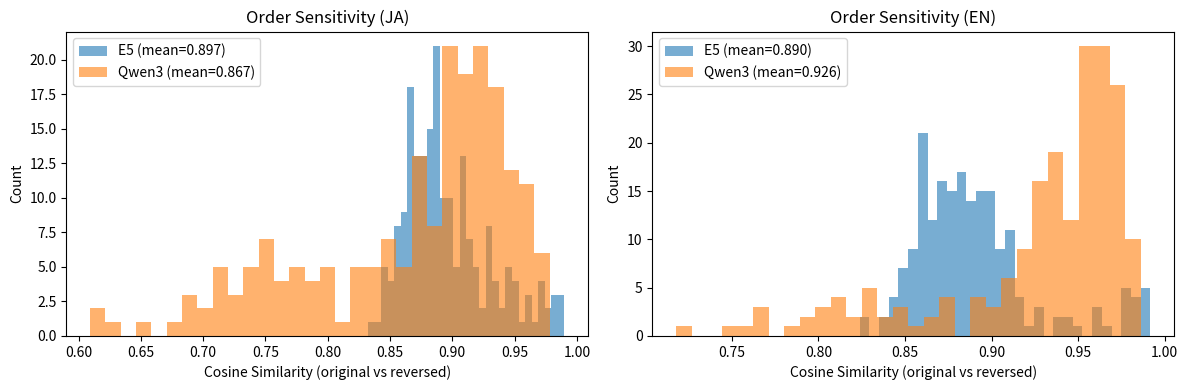

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, lang, oe5, oqwen in [
    (axes[0], "JA", order_e5_ja, order_qwen_ja),
    (axes[1], "EN", order_e5_en, order_qwen_en),
]:
    ax.hist(oe5, bins=30, alpha=0.6, label=f"E5 (mean={np.mean(oe5):.3f})")
    ax.hist(oqwen, bins=30, alpha=0.6, label=f"Qwen3 (mean={np.mean(oqwen):.3f})")
    ax.set_xlabel("Cosine Similarity (original vs reversed)")
    ax.set_ylabel("Count")
    ax.set_title(f"Order Sensitivity ({lang})")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "104_order_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. チャンク vs 全文 比較

3つの戦略を比較:
- (A) 全文 → 1ベクトル/記事
- (B) 512トークンチャンク → max-sim集約
- (C) 512トークンチャンク → 個別検索

In [11]:
def evaluate_strategies_abc(articles, model, tokenizer, prefix, lang, chunk_size=512, max_tokens=8192):
    """3戦略 (A) 全文, (B) max-sim, (C) 個別検索 を比較。
    全文は max_tokens で打ち切る。"""
    results = {}

    # === (A) 全文1ベクトル ===
    full_texts = []
    full_aids = []
    for art in articles:
        ids = tokenizer.encode(art["text"], add_special_tokens=False)[:max_tokens]
        text = tokenizer.decode(ids, skip_special_tokens=True)
        full_texts.append(text)
        full_aids.append(art["article_id"])
    full_aids = np.array(full_aids)

    # 長文を1件ずつencode → OOM回避
    embs_a_list = []
    for i, t in enumerate(tqdm(full_texts, desc="Full-text encode")):
        inp = f"{prefix}{t}" if prefix else t
        emb = model.encode([inp], batch_size=1,
                           normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
        embs_a_list.append(emb[0])
        if i % 20 == 0:
            torch.cuda.empty_cache()
    embs_a = np.array(embs_a_list)
    del embs_a_list
    torch.cuda.empty_cache()

    # クエリ: 各記事の2番目の段落、正解: その記事の全文ベクトル
    query_texts = []
    query_aids = []
    for art in articles:
        if len(art["paragraphs"]) >= 2:
            query_texts.append(art["paragraphs"][1])
            query_aids.append(art["article_id"])

    texts_q = [f"{prefix}{t}" for t in query_texts] if prefix else query_texts
    query_embs = model.encode(texts_q, batch_size=32,
                              normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
    del texts_q
    torch.cuda.empty_cache()

    # Recall@10: クエリの記事が全文DBのTop-10に含まれるか
    hits = 0
    mrrs_a = []
    for i, qaid in enumerate(query_aids):
        sims = query_embs[i] @ embs_a.T
        topk = np.argsort(sims)[-10:][::-1]
        if np.where(full_aids[topk] == qaid)[0].size > 0:
            hits += 1
            rank = np.where(full_aids[topk] == qaid)[0][0] + 1
            mrrs_a.append(1.0 / rank)
        else:
            mrrs_a.append(0.0)

    results["A_fulltext"] = {
        "Recall@10": hits / len(query_aids),
        "MRR": float(np.mean(mrrs_a)),
        "n_vectors": len(full_texts),
    }

    del embs_a, query_embs, full_texts, query_texts, query_aids, full_aids, mrrs_a
    gc.collect()
    torch.cuda.empty_cache()

    # === (C) 個別チャンク検索 ===
    all_chunks = []
    all_chunk_aids = []
    for art in articles:
        chunks = chunk_fixed_token(art["text"], tokenizer, chunk_size, overlap=0)
        if len(chunks) >= 2:
            all_chunks.extend(chunks)
            all_chunk_aids.extend([art["article_id"]] * len(chunks))
    all_chunk_aids = np.array(all_chunk_aids)

    texts_c = [f"{prefix}{c}" for c in all_chunks] if prefix else all_chunks
    embs_c = model.encode(texts_c, batch_size=32,
                          normalize_embeddings=True, show_progress_bar=True).astype(np.float32)
    del texts_c
    torch.cuda.empty_cache()

    ret_c = compute_retrieval_metrics(embs_c, all_chunk_aids, k=10)
    results["C_individual"] = {
        "Recall@10": ret_c["Recall@10"],
        "MRR": ret_c["MRR"],
        "n_vectors": len(all_chunks),
    }

    # === (B) max-sim集約 ===
    article_chunk_indices = {}
    for i, aid in enumerate(all_chunk_aids):
        if aid not in article_chunk_indices:
            article_chunk_indices[aid] = []
        article_chunk_indices[aid].append(i)

    unique_aids = np.array(sorted(article_chunk_indices.keys()))

    rng = np.random.default_rng(SEED)
    n_queries_b = min(1000, len(embs_c))
    query_ids_b = rng.choice(len(embs_c), n_queries_b, replace=False)

    recalls_b = []
    mrrs_b = []
    for qid in query_ids_b:
        q_aid = all_chunk_aids[qid]
        q_emb = embs_c[qid]

        article_scores = []
        for aid in unique_aids:
            indices = article_chunk_indices[aid]
            indices_filtered = [idx for idx in indices if idx != qid]
            if not indices_filtered:
                article_scores.append(-2.0)
                continue
            sims = q_emb @ embs_c[indices_filtered].T
            article_scores.append(float(np.max(sims)))

        article_scores = np.array(article_scores)
        topk_articles = unique_aids[np.argsort(article_scores)[-10:][::-1]]

        if q_aid in topk_articles:
            recalls_b.append(1.0)
            rank = np.where(topk_articles == q_aid)[0][0] + 1
            mrrs_b.append(1.0 / rank)
        else:
            recalls_b.append(0.0)
            mrrs_b.append(0.0)

    results["B_maxsim"] = {
        "Recall@10": float(np.mean(recalls_b)),
        "MRR": float(np.mean(mrrs_b)),
        "n_vectors": len(all_chunks),
    }

    del embs_c, all_chunks, all_chunk_aids
    gc.collect()
    torch.cuda.empty_cache()

    return results

In [12]:
csv_path_abc = os.path.join(DATA_DIR, "104_abc_results.csv")
if os.path.exists(csv_path_abc):
    print(f"Results already exist at {csv_path_abc} — skipping computation, loading from file")
    df_abc = pd.read_csv(csv_path_abc)
    all_abc_results = df_abc.to_dict("records")
    print(f"Loaded {len(df_abc)} rows")
else:
    all_abc_results = []

    # E5 (max 512 tokens)
    print(f"[VRAM before E5] {_vram_mb():.0f} MB")
    model_e5 = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")
    print(f"[VRAM after E5 load] {_vram_mb():.0f} MB")

    for lang, articles in [("ja", long_ja), ("en", long_en)]:
        print(f"\nE5-base ({lang}):")
        abc = evaluate_strategies_abc(articles, model_e5, tokenizer_e5, "passage: ", lang,
                                      max_tokens=512)
        for strategy, metrics in abc.items():
            all_abc_results.append({"model": "E5-base", "lang": lang, "strategy": strategy, **metrics})
            print(f"  {strategy}: R@10={metrics['Recall@10']:.4f}, MRR={metrics['MRR']:.4f}, "
                  f"vectors={metrics['n_vectors']}")
    del model_e5
    clear_gpu()
    print(f"[VRAM after E5 cleanup] {_vram_mb():.0f} MB")

    # Qwen3 (max 4096 tokens — 8192はVRAM 24GBでOOM)
    print(f"\n[VRAM before Qwen3] {_vram_mb():.0f} MB")
    model_qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")
    print(f"[VRAM after Qwen3 load] {_vram_mb():.0f} MB")

    for lang, articles in [("ja", long_ja), ("en", long_en)]:
        print(f"\nQwen3-0.6B ({lang}):")
        abc = evaluate_strategies_abc(articles, model_qwen, tokenizer_qwen, "", lang,
                                      max_tokens=4096)
        for strategy, metrics in abc.items():
            all_abc_results.append({"model": "Qwen3-0.6B", "lang": lang, "strategy": strategy, **metrics})
            print(f"  {strategy}: R@10={metrics['Recall@10']:.4f}, MRR={metrics['MRR']:.4f}, "
                  f"vectors={metrics['n_vectors']}")
    del model_qwen
    clear_gpu()
    print(f"[VRAM after Qwen3 cleanup] {_vram_mb():.0f} MB")

    df_abc = pd.DataFrame(all_abc_results)
    df_abc.to_csv(csv_path_abc, index=False)
    print(f"\nSaved: {csv_path_abc} ({len(df_abc)} rows)")

print("\n" + df_abc.to_string(index=False))

[VRAM before E5] 0 MB


Token indices sequence length is longer than the specified maximum sequence length for this model (1572 > 512). Running this sequence through the model will result in indexing errors


[VRAM after E5 load] 1061 MB

E5-base (ja):


Full-text encode:   0%|          | 0/200 [00:00<?, ?it/s]

Batches:   0%|          | 0/91 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/107 [00:00<?, ?it/s]

  A_fulltext: R@10=0.8350, MRR=0.7314, vectors=200
  C_individual: R@10=0.7087, MRR=0.9039, vectors=3394
  B_maxsim: R@10=0.9780, MRR=0.9088, vectors=3394

Qwen3-0.6B (en):


Full-text encode:   0%|          | 0/200 [00:00<?, ?it/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

  A_fulltext: R@10=0.9500, MRR=0.9308, vectors=200
  C_individual: R@10=0.9032, MRR=0.9709, vectors=2782
  B_maxsim: R@10=0.9990, MRR=0.9742, vectors=2782
[VRAM after Qwen3 cleanup] 1070 MB

Saved: ../data/104_abc_results.csv (12 rows)

     model lang     strategy  Recall@10      MRR  n_vectors
   E5-base   ja   A_fulltext   0.815000 0.691359        200
   E5-base   ja C_individual   0.614761 0.843012       2889
   E5-base   ja     B_maxsim   0.956000 0.847658       2889
   E5-base   en   A_fulltext   0.950000 0.935667        200
   E5-base   en C_individual   0.862642 0.959173       2982
   E5-base   en     B_maxsim   0.997000 0.962960       2982
Qwen3-0.6B   ja   A_fulltext   0.835000 0.731367        200
Qwen3-0.6B   ja C_individual   0.708683 0.903933       3394
Qwen3-0.6B   ja     B_maxsim   0.978000 0.908803       3394
Qwen3-0.6B   en   A_fulltext   0.950000 0.930833        200
Qwen3-0.6B   en C_individual   0.903156 0.970930       2782
Qwen3-0.6B   en     B_maxsim   0.999000 0.9

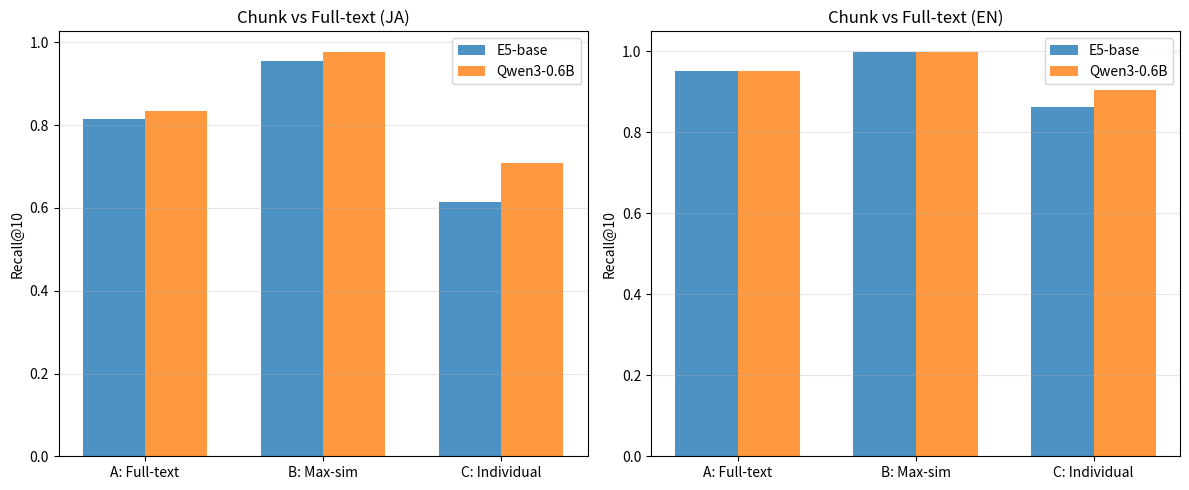

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, lang in zip(axes, ["ja", "en"]):
    subset = df_abc[df_abc["lang"] == lang]
    x = np.arange(3)
    width = 0.35
    for i, model_name in enumerate(["E5-base", "Qwen3-0.6B"]):
        model_data = subset[subset["model"] == model_name].sort_values("strategy")
        ax.bar(x + i * width, model_data["Recall@10"], width,
               label=model_name, alpha=0.8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(["A: Full-text", "B: Max-sim", "C: Individual"])
    ax.set_ylabel("Recall@10")
    ax.set_title(f"Chunk vs Full-text ({lang.upper()})")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "104_abc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. まとめ

In [14]:
# 全結果を統合して保存
summary = {
    "position_sensitivity": {
        "e5_ja": {i: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                  for i, v in pos_e5_ja.items() if len(v) > 0},
        "e5_en": {i: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                  for i, v in pos_e5_en.items() if len(v) > 0},
        "qwen_ja": {i: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                    for i, v in pos_qwen_ja.items() if len(v) > 0},
        "qwen_en": {i: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                    for i, v in pos_qwen_en.items() if len(v) > 0},
    },
    "order_sensitivity": {
        "e5_ja": {"mean": float(np.mean(order_e5_ja)), "std": float(np.std(order_e5_ja))},
        "e5_en": {"mean": float(np.mean(order_e5_en)), "std": float(np.std(order_e5_en))},
        "qwen_ja": {"mean": float(np.mean(order_qwen_ja)), "std": float(np.std(order_qwen_ja))},
        "qwen_en": {"mean": float(np.mean(order_qwen_en)), "std": float(np.std(order_qwen_en))},
    },
}

# 104の統合結果 (df_trunc and df_abc already saved as intermediate)
combined_rows = []
# truncation results
for _, r in df_trunc.iterrows():
    combined_rows.append({
        "model": r["model"], "lang": r["lang"],
        "strategy": f"truncate_{int(r['trunc_tokens'])}",
        "Recall@10": r["Recall@10"], "MRR": r["MRR"],
    })
# ABC results
for _, r in df_abc.iterrows():
    combined_rows.append({
        "model": r["model"], "lang": r["lang"],
        "strategy": r["strategy"],
        "Recall@10": r["Recall@10"], "MRR": r["MRR"],
    })

df_104 = pd.DataFrame(combined_rows)
df_104.to_csv(os.path.join(DATA_DIR, "104_long_context_results.csv"), index=False)

print("All results saved.")
print(f"\nKey findings:")
print(f"  Order sensitivity (original vs reversed cos-sim):")
print(f"    E5 JA: {np.mean(order_e5_ja):.4f}, Qwen3 JA: {np.mean(order_qwen_ja):.4f}")
print(f"    E5 EN: {np.mean(order_e5_en):.4f}, Qwen3 EN: {np.mean(order_qwen_en):.4f}")

All results saved.

Key findings:
  Order sensitivity (original vs reversed cos-sim):
    E5 JA: 0.8966, Qwen3 JA: 0.8671
    E5 EN: 0.8903, Qwen3 EN: 0.9265


## 7. 評価・考察

### 1. 先頭偏重バイアス — Qwen3 で顕著に存在

全文 embedding と各段落 embedding のコサイン類似度（位置感度テスト）:

| 位置 | E5 JA | E5 EN | Qwen3 JA | Qwen3 EN |
|------|-------|-------|----------|----------|
| p1 (先頭) | 0.888 | 0.914 | **0.864** | **0.838** |
| p2 | 0.864 | 0.888 | 0.587 | 0.747 |
| p5 | 0.870 | 0.836 | 0.584 | 0.623 |
| p10 (末尾) | 0.830 | 0.816 | 0.535 | 0.601 |

- **Qwen3 は強い先頭偏重**を示す。JA では p1=0.864 → p2=0.587 と急落（−0.28）。全文 embedding が先頭段落に支配されている。
- **E5 は比較的フラット**。p1→p10 の低下は 0.06〜0.10 程度で、先頭偏重は軽微。ただし E5 は max_tokens=512 で打ち切られるため、後方段落はそもそも入力に含まれていない可能性が高い。
- Qwen3 の先頭偏重は、長文を1ベクトルに集約する戦略の限界を示している。

### 2. 打ち切り長さ — 256トークン以降は収穫逓減

| モデル | 言語 | 128tok | 256tok | 512tok | 1024tok | 4096tok |
|--------|------|--------|--------|--------|---------|---------|
| E5 | JA | 0.525 | **0.531** | 0.528 | — | — |
| E5 | EN | **0.837** | 0.833 | 0.831 | — | — |
| Qwen3 | JA | 0.558 | 0.574 | 0.578 | 0.579 | **0.580** |
| Qwen3 | EN | 0.883 | 0.891 | **0.893** | 0.893 | 0.893 |

- **E5**: 128トークンでほぼ飽和。256以降は横ばい〜微減。
- **Qwen3**: 512トークンでほぼ飽和。1024→4096 は JA で +0.001、EN で変化なし。
- 長コンテキスト能力は段落単位の検索では活かしきれない。テキストの意味的中心は先頭数百トークンに集中している。

### 3. 順序依存性 — Qwen3 JA で中程度の感度

正順 vs 逆順の cos 類似度:

| モデル | JA (mean±std) | EN (mean±std) |
|--------|--------------|--------------|
| E5 | 0.897 ± 0.035 | 0.890 ± 0.036 |
| Qwen3 | 0.867 ± 0.083 | 0.927 ± 0.056 |

- E5 は JA/EN とも 0.89 前後で安定。512トークン打ち切りにより、実質的に先頭段落しか見ていないため順序変更の影響が小さい。
- **Qwen3 JA は 0.867 と最も低く、std=0.083 とばらつきも大きい**。先頭偏重のため、逆順にすると embedding が大きく変わる記事がある。
- Qwen3 EN は 0.927 と高い。英語は段落間の意味的重複が大きく、順序変更の影響が緩和されている可能性。

### 4. チャンク vs 全文 — max-sim 集約が圧勝

| 戦略 | E5 JA | E5 EN | Qwen3 JA | Qwen3 EN |
|------|-------|-------|----------|----------|
| (A) 全文1ベクトル | 0.815 | 0.950 | 0.835 | 0.950 |
| (B) チャンク max-sim | **0.956** | **0.997** | **0.978** | **0.999** |
| (C) チャンク個別 | 0.615 | 0.863 | 0.709 | 0.903 |

- **max-sim 集約 (B) が全条件で最良**。記事レベルの検索には、チャンクを複数持ち最も類似するチャンクのスコアで代表する方式が最も効果的。
- 全文1ベクトル (A) は 200 記事中の Top-10 検索なので R@10 は高めに出るが、MRR では B に劣る（JA: 0.69 vs 0.85）。
- 個別チャンク検索 (C) は記事内の異なるチャンク同士が競合するため R@10 が低い。NB102 の結果（1000記事、オーバーラップあり）とは条件が異なる点に注意。

### 5. 総合考察と NB105 への示唆

1. **Qwen3 は先頭偏重が強い**。長文を1ベクトルに圧縮する用途では先頭のみが支配的になるため、チャンキングが必須。
2. **打ち切りは 256〜512 トークンで十分**。長コンテキスト能力の恩恵は段落レベルの検索ではほぼ見られない。
3. **実用的な検索戦略は max-sim 集約**。ただし計算コストが O(記事数 × チャンク数) なので、大規模データでは近似が必要。
4. **NB105 のチャンキング戦略比較**では、NB102 で確立した固定長チャンク（E5: 256/64, Qwen3: 512/128）を基準とし、max-sim を記事レベル検索に使うパイプラインを評価すべき。